# ResU-Net Training
**Dataset layout expected:**
```
training/
  image/  001.tif  002.tif  ...
  mask/   001.tif  002.tif  ...
validation/
  image/  001.tif  002.tif  ...
  mask/   001.tif  002.tif  ...
```
Image tiles : (H, W, 3) RGB GeoTIFF  
Mask tiles  : (H, W) single-band GeoTIFF, pixel values = class index

## 0 · Config — edit here only

In [ ]:
# ── paths ──────────────────────────────────────────────────────────────────
TRAIN_IMG_DIR  = "datasets/training/images"
TRAIN_MASK_DIR = "datasets/training/masks"
VAL_IMG_DIR    = "datasets/validation/images"
VAL_MASK_DIR   = "datasets/validation/masks"
CHECKPOINT_DIR = "checkpoints"

# ── model ──────────────────────────────────────────────────────────────────
BACKBONE     = "resnet34"   # "resnet34" | "resnet50"
CLASS_MAP  = {0: "others(ignored)", 1: "building", 2: "road", 3: "waterbody", 4: "vegetation"}  # index 0 = others, excluded via IGNORE_INDEX
NUM_CLASSES  = len(CLASS_MAP)   # 0=others(ignored), 1=building, 2=road, 3=waterbody, 4=vegetation

# Class index 0 (background/unlabelled) is excluded from loss and metrics.
# Masks should use 0 for pixels you want ignored, 1-4 for the real classes.
PRETRAINED   = True

# ── dataset Normalization ──────────────────────────────────────────────────
IMAGENET_NORM_MEAN = [0.485, 0.456, 0.406] 
IMAGENET_NORM_STD = [0.229, 0.224, 0.225]

# ── training ───────────────────────────────────────────────────────────────
EPOCHS       = 5
BATCH_SIZE   = 8
LR           = 3e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP    = 1.0          # max gradient norm
FREEZE_EPOCHS = 5           # keep encoder frozen for first N epochs

# ── scheduler ──────────────────────────────────────────────────────────────
WARMUP_EPOCHS = 3
LR_MIN        = LR * 0.01  # cosine decay floor

# ── misc ───────────────────────────────────────────────────────────────────
NUM_WORKERS   = 0
IGNORE_INDEX  = 0           # class 0 = unlabelled/background — excluded from loss & metrics
SEED          = 42

## 1 · Imports & setup

In [ ]:
import os, json, math, time
from pathlib import Path

import numpy as np
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast

from model   import ResUNet
from losses  import ComboLoss
from metrics import SegmentationMetrics

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)

print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cpu


## 2 · Dataset

In [ ]:
class TileDataset(Dataset):
    """
    Loads paired image/mask GeoTIFF tiles.
    Matches files by stem (e.g. '001.tif' in both folders).
    """

    # ImageNet normalisation constants
    MEAN = np.array(IMAGENET_NORM_MEAN, dtype=np.float32)
    STD  = np.array(IMAGENET_NORM_STD, dtype=np.float32)

    def __init__(self, img_dir: str, mask_dir: str, augment: bool = False):
        img_dir, mask_dir = Path(img_dir), Path(mask_dir)

        img_stems  = {p.stem for p in img_dir.glob("*.tif")}
        mask_stems = {p.stem for p in mask_dir.glob("*.tif")}
        matched    = sorted(img_stems & mask_stems)

        if not matched:
            raise FileNotFoundError(
                f"No matched image/mask pairs found in\n"
                f"  images : {img_dir}\n  masks  : {mask_dir}"
            )

        self.img_paths  = [img_dir  / f"{s}.tif" for s in matched]
        self.mask_paths = [mask_dir / f"{s}.tif" for s in matched]
        self.augment    = augment
        print(f"  {len(matched)} tile pairs found in {img_dir.parent.name}/")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # ── load image ────────────────────────────────────────────────────
        with rasterio.open(self.img_paths[idx]) as src:
            bands = min(src.count, 3)
            img   = src.read(list(range(1, bands + 1))).astype(np.float32)  # (C,H,W)

        # scale 0-1
        img = img.astype(np.float32) / 255.0
        # img = np.clip(img, 0, 1) #optional

        img = np.transpose(img, (1, 2, 0))           # BGR to RGB

        # ── load mask ─────────────────────────────────────────────────────
        with rasterio.open(self.mask_paths[idx]) as src:
            mask = src.read(1).astype(np.int64)       # (H, W)

        # ── augmentation (horizontal + vertical flip) ─────────────────────
        if self.augment:
            if np.random.rand() > 0.5:
                img  = img[:, ::-1, :].copy()
                mask = mask[:, ::-1].copy()
            if np.random.rand() > 0.5:
                img  = img[::-1, :, :].copy()
                mask = mask[::-1, :].copy()

        # ── ImageNet normalise → tensor ───────────────────────────────────
        img = (img - self.MEAN) / self.STD
        img_t  = torch.from_numpy(img.transpose(2, 0, 1))   # (3, H, W)
        mask_t = torch.from_numpy(mask)                      # (H, W)  long
        return img_t, mask_t


train_ds = TileDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment=True)
val_ds   = TileDataset(VAL_IMG_DIR,   VAL_MASK_DIR,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nBatches per epoch → train: {len(train_loader)}  val: {len(val_loader)}")

  162 tile pairs found in training/
  69 tile pairs found in validation/

Batches per epoch → train: 20  val: 9


## plotting some of the images

c:\Users\user\anaconda3\envs\geoai\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


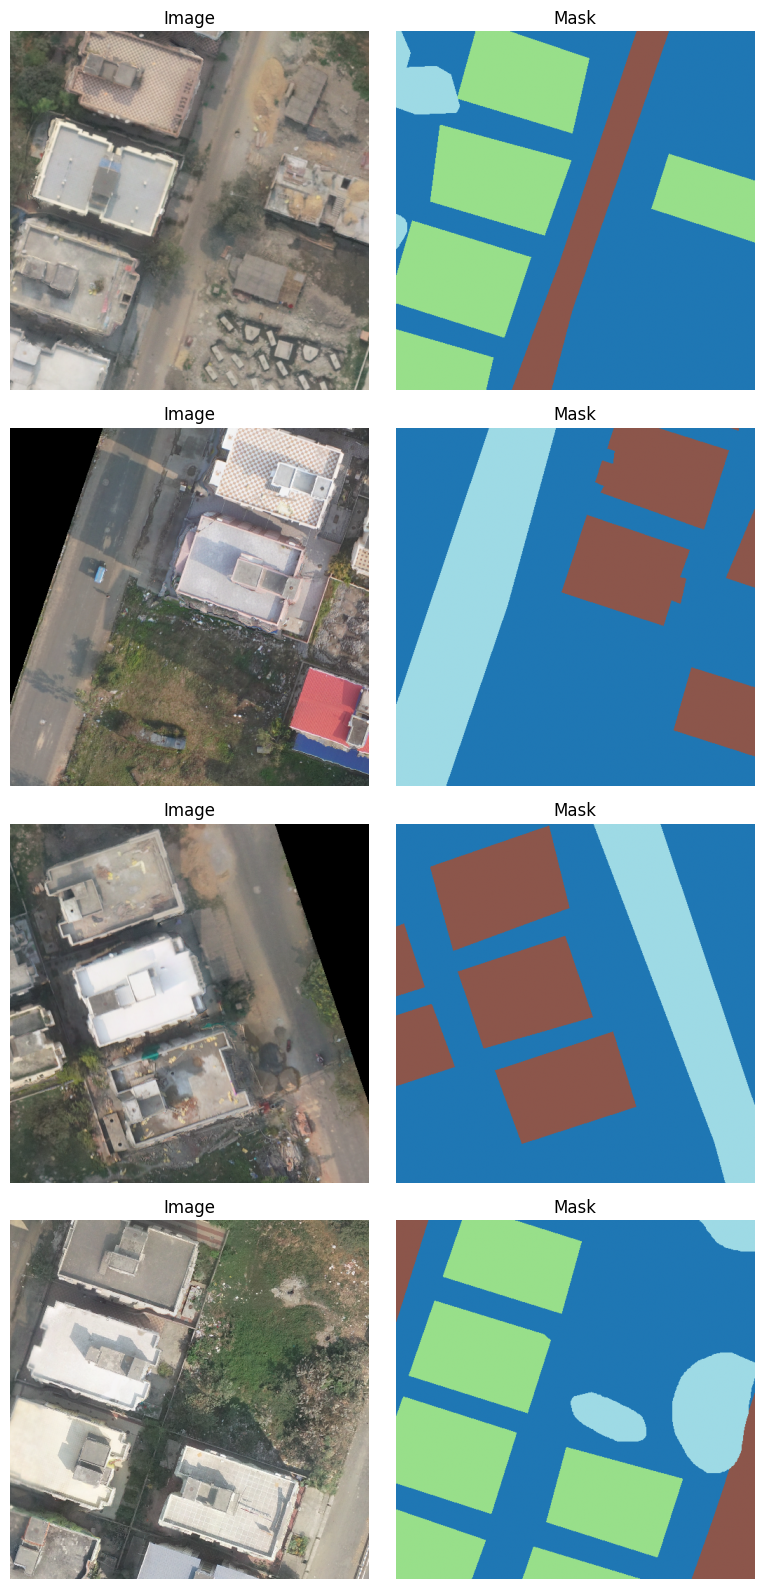

In [ ]:
from utils import plot_batch
plot_batch(train_loader, class_map=CLASS_MAP, mean=IMAGENET_NORM_MEAN, std=IMAGENET_NORM_STD, n=4)

## 3 · Model, loss, optimiser, scheduler

In [ ]:
# ── model ──────────────────────────────────────────────────────────────────
model = ResUNet(
    num_classes=NUM_CLASSES,
    backbone=BACKBONE,
    pretrained=PRETRAINED,
    freeze_encoder=(FREEZE_EPOCHS > 0),
).to(DEVICE)

p = model.count_parameters()
print(f"Parameters  total={p['total']:,}  trainable={p['trainable']:,}  "
      f"frozen={p['frozen']:,}")

# ── loss ───────────────────────────────────────────────────────────────────
criterion = ComboLoss(
    alpha=0.5,           # 0.5 × Focal + 0.5 × Dice
    focal_gamma=2.0,
    ignore_index=IGNORE_INDEX,
).to(DEVICE)

# ── optimiser (differential LR: encoder gets 0.1×) ─────────────────────────
optimizer = torch.optim.AdamW(
    model.get_param_groups(LR),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

# ── scheduler: linear warmup → cosine decay ────────────────────────────────
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / max(WARMUP_EPOCHS, 1)   # linear ramp
    progress = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
    cos_val  = 0.5 * (1 + math.cos(math.pi * progress))
    min_frac = LR_MIN / LR
    return min_frac + (1 - min_frac) * cos_val

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── mixed precision scaler ─────────────────────────────────────────────────
scaler = GradScaler(enabled=(DEVICE.type == "cuda"))

# ── metrics ────────────────────────────────────────────────────────────────
train_meter = SegmentationMetrics(CLASS_MAP, IGNORE_INDEX)
val_meter   = SegmentationMetrics(CLASS_MAP, IGNORE_INDEX)

Parameters  total=26,612,017  trainable=5,327,345  frozen=21,284,672


## 4 · Training loop

In [ ]:
best_miou = 0.0
history   = []

for epoch in range(EPOCHS):
    print(
        f"\n{'='*50}\n"
        f"Epoch [{epoch:03d}/{EPOCHS-1}]\n"
    )
    t0 = time.time()

    # ── unfreeze encoder after FREEZE_EPOCHS ──────────────────────────────
    if epoch == FREEZE_EPOCHS and FREEZE_EPOCHS > 0:
        model.unfreeze_encoder()
        # Rebuild optimiser so unfrozen encoder params get their own LR
        optimizer = torch.optim.AdamW(
            model.get_param_groups(LR),
            lr=LR, weight_decay=WEIGHT_DECAY,
        )
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
        print(f"\n[Epoch {epoch}] Encoder unfrozen — encoder LR = {LR * 0.1:.1e}")

    # ──────────────────────────────────────────────────────────────────────
    # TRAIN
    # ──────────────────────────────────────────────────────────────────────
    model.train()
    train_meter.reset()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs  = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        with autocast(device_type= DEVICE.type, enabled=(DEVICE.type == "cuda")):
            logits = model(imgs)
            loss, _ = criterion(logits, masks)

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        train_loss  += loss.item()
        train_meter.update(logits.detach(), masks)

    train_loss /= len(train_loader)
    train_miou  = train_meter.compute()["mIoU"]
    train_meter.log_status()


    # ──────────────────────────────────────────────────────────────────────
    # VALIDATE
    # ──────────────────────────────────────────────────────────────────────
    model.eval()
    val_meter.reset()
    val_loss = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            with autocast(device_type= DEVICE.type, enabled=(DEVICE.type == "cuda")):
                logits = model(imgs)
                loss, _ = criterion(logits, masks)

            val_loss += loss.item()
            val_meter.update(logits, masks)

    val_loss /= len(val_loader)
    val_metrics = val_meter.compute()
    val_miou    = val_metrics["mIoU"]

    scheduler.step()
    current_lr = scheduler.get_last_lr()[-1]
    elapsed    = time.time() - t0

    # ──────────────────────────────────────────────────────────────────────
    # CHECKPOINT
    # ──────────────────────────────────────────────────────────────────────
    ckpt = {
        "epoch"   : epoch,
        "model"   : model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "metrics" : val_metrics,
    }

    # Always keep the latest checkpoint
    torch.save(ckpt, f"{CHECKPOINT_DIR}/last.pt")

    # Save best-mIoU checkpoint
    if val_miou > best_miou:
        best_miou = val_miou
        torch.save(ckpt, f"{CHECKPOINT_DIR}/best.pt")
        best_tag = " ◀ best"
    else:
        best_tag = ""

    # ──────────────────────────────────────────────────────────────────────
    # LOG
    # ──────────────────────────────────────────────────────────────────────
    history.append({
        "epoch": epoch,
        "train_loss": round(train_loss, 5),
        "train_miou": train_miou,
        "val_loss"  : round(val_loss, 5),
        "val_miou"  : val_miou,
        "lr"        : round(current_lr, 8),
    })

    print(
        f"{'-'*50}\n"
        f"Train | Loss: {train_loss:.4f} | mIoU: {train_miou:.4f}\n"
        f"Val   | Loss: {val_loss:.4f} | mIoU: {val_miou:.4f}\n"
        f"{'-'*50}\n"
        f"LR: {current_lr:.2e} | Time: {elapsed:.0f}s {best_tag}\n"
        f"{'='*50}"
    )

    train_meter.log_status()
    val_meter.log_status()

# Save history
with open(f"{CHECKPOINT_DIR}/history.json", "w") as f:
    json.dump(history, f, indent=2)

print(f"\nDone. Best val mIoU = {best_miou:.4f}")

Ep 000/4 | train  loss=1.2985  mIoU=0.1417 | val  loss=0.8791  mIoU=0.2750 | lr=2.00e-04  442s ◀ best


KeyboardInterrupt: 

## 5 · Per-class breakdown (best model)

In [ ]:
# Reload best weights and evaluate on validation set
ckpt = torch.load(f"{CHECKPOINT_DIR}/best.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model"])

model.eval()
val_meter.reset()

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs  = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        logits = model(imgs)
        val_meter.update(logits, masks)

val_meter.pretty_print()

## 6 · Loss & mIoU curves

In [ ]:
import matplotlib.pyplot as plt

epochs     = [h["epoch"]      for h in history]
train_loss = [h["train_loss"] for h in history]
val_loss   = [h["val_loss"]   for h in history]
train_miou = [h["train_miou"] for h in history]
val_miou   = [h["val_miou"]   for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs, train_loss, label="train", linewidth=1.8)
ax1.plot(epochs, val_loss,   label="val",   linewidth=1.8)
ax1.set_title("Loss (Focal + Dice)")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_miou, label="train", linewidth=1.8)
ax2.plot(epochs, val_miou,   label="val",   linewidth=1.8)
ax2.axhline(best_miou, linestyle="--", color="grey", alpha=0.6,
            label=f"best {best_miou:.4f}")
ax2.set_title("mIoU")
ax2.set_xlabel("Epoch")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/training_curves.png", dpi=120)
plt.show()